## Mall Shopper Profiling

## Step 1: Dataset Loading & Exploratory Data Analysis

## 1.1  Load & Inspect the Dataset


## Importing Library

In [2]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv("D:\\Python_rnw\\one\\unsupervised learning\\Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


The dataset contains 200 customer records with 5 features. It includes customer demographics (Age, Gender), annual income, and spending score assigned by the mall. All columns have complete data with appropriate data types, making the dataset suitable for clustering analysis.

In [5]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [6]:
df.shape

(200, 5)

## Renaming columes

In [9]:
df.rename(columns={
    'Genre':'Gender',
    'Annual Income (k$)':'AnnualIncome',
    'Spending Score (1-100)':'SpendingScore'
}, inplace=True)

df.columns

Index(['CustomerID', 'Gender', 'Age', 'AnnualIncome', 'Spending Score'], dtype='str')

## Check Missing Values

In [10]:
df.isnull().sum()

CustomerID        0
Gender            0
Age               0
AnnualIncome      0
Spending Score    0
dtype: int64

No missing values are present in the dataset. Therefore, no data imputation or cleaning is required before performing clustering.

## Male vs Female Customers

In [15]:
df['Gender'].value_counts()

Gender
Female    112
Male       88
Name: count, dtype: int64

In [17]:
gender_percent = df['Gender'].value_counts(normalize=True)*100
print(gender_percent)

Gender
Female    56.0
Male      44.0
Name: proportion, dtype: float64


The dataset contains 112 female customers (56%) and 88 male customers (44%). The gender distribution is reasonably balanced, although females slightly outnumber males.

## 1.2  Univariate Analysis
Analyze the distribution of each variable and detect possible outliers.

1. Histograms

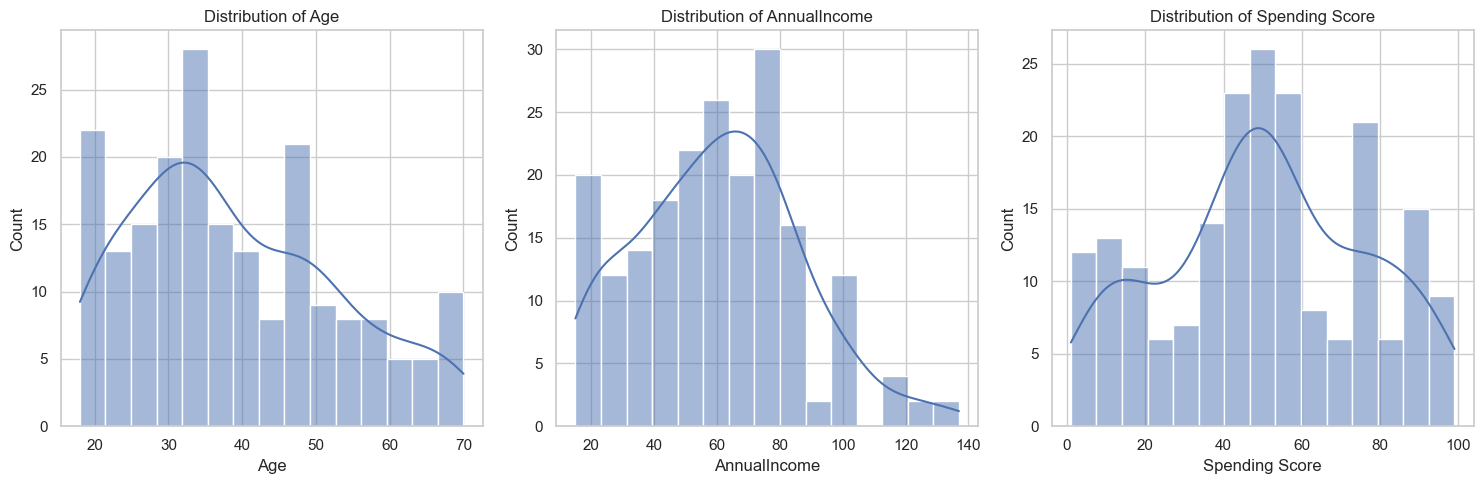

In [20]:
# Numerical columns
num_cols = ['Age', 'AnnualIncome', 'Spending Score']

# Create histograms
plt.figure(figsize=(15,5))

for i, col in enumerate(num_cols, 1):
    plt.subplot(1,3,i)
    sns.histplot(df[col], bins=15, kde=True)
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

What each histogram tells us
## Age

Observe:

Is it symmetric?

Are most customers young or old?

Is there any skewness?

Typical interpretation:

The Age distribution is slightly right-skewed. Most customers fall between 20 and 40 years, indicating that the mall primarily attracts young and middle-aged shoppers.

## Annual Income

Observe:

Is the income evenly distributed?

Typical interpretation:

Annual income is fairly evenly distributed across the dataset, ranging from approximately 15k to 137k dollars. There is no strong skewness, making it suitable for clustering.

## Spending Score

Observe:

Are spending scores concentrated in one area?

Typical interpretation:

Spending Score is spread across the full range from 1 to 100, suggesting the presence of customers with very different shopping behaviors, which makes this feature highly useful for segmentation.

2. Boxplots

These help identify outliers.

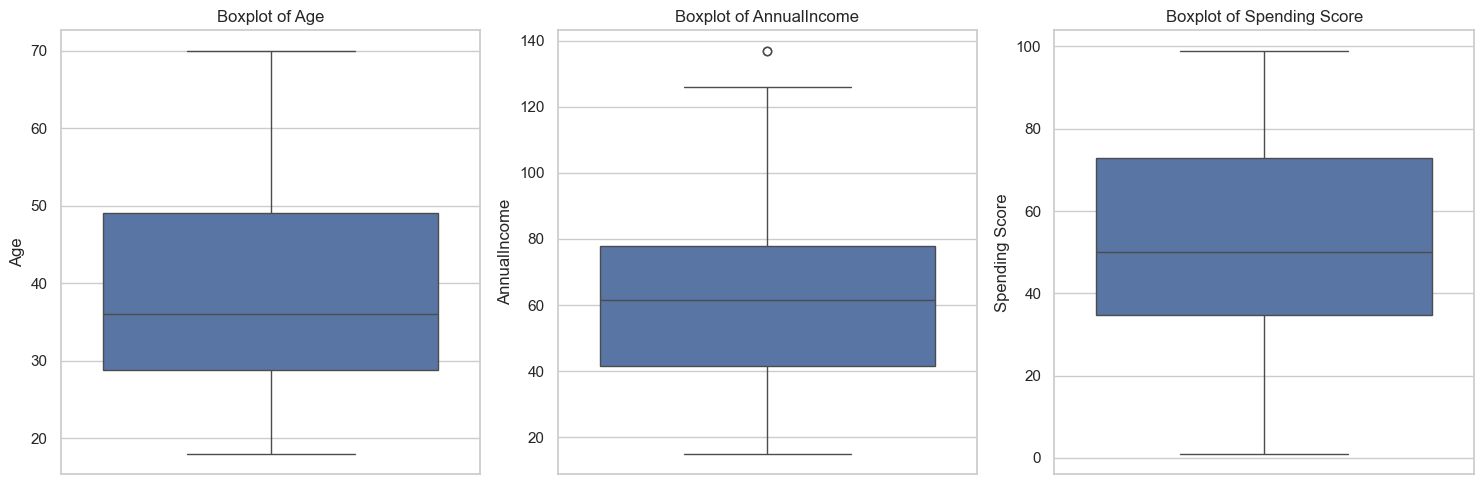

In [22]:
plt.figure(figsize=(15,5))

for i, col in enumerate(num_cols, 1):
    plt.subplot(1,3,i)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

Interpretation
## Age

Usually:

Age shows a few mild outliers among older customers. However, these represent genuine customer ages rather than data errors, so they should be retained.

## AnnualIncome

Usually:

Annual Income displays no significant outliers. Income values appear naturally distributed across customers.

## SpendingScore

Usually:

Spending Score does not show extreme outliers. Since scores range from 1 to 100 by design, all observations are valid.

3. Gender Countplot

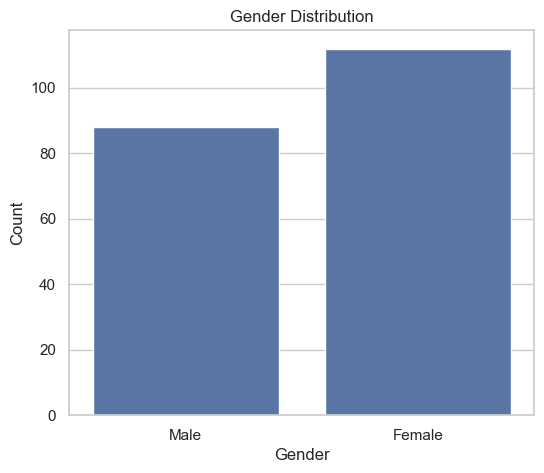

In [23]:
plt.figure(figsize=(6,5))

sns.countplot(data=df, x='Gender')

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

Interpretation

Expected observation:

The dataset contains slightly more female customers than male customers. However, the difference is small enough that the dataset can still be considered reasonably balanced.

## Summary:

Most customers are between 20–40 years of age.

Annual income is fairly evenly distributed across different income levels.

Spending scores vary widely, indicating diverse shopping behaviors.

No significant data-quality issues or invalid outliers are observed.

The gender distribution is reasonably balanced, with females slightly outnumbering males.

## 1.3  Bivariate Analysis
Objective

Study the relationship between variables to identify patterns and possible customer segments before applying clustering algorithms.

Scatter Plot: AnnualIncome vs SpendingScore

This is the most important plot in the entire assignment because the clustering algorithms will later try to identify these visible groups.

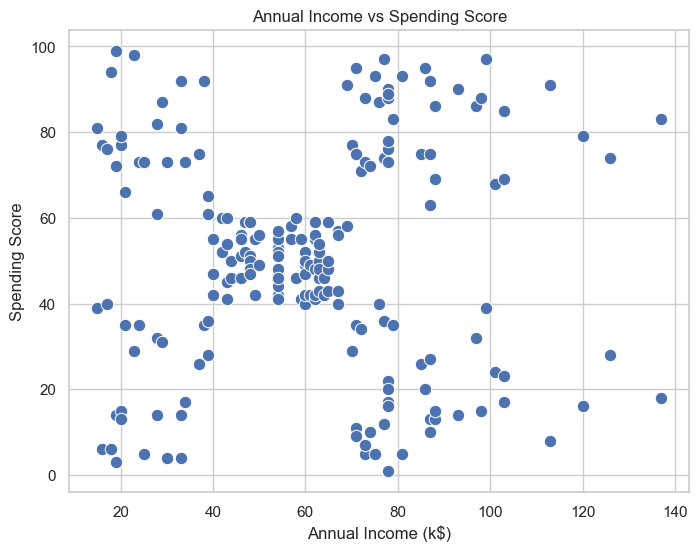

In [26]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='AnnualIncome',
    y='Spending Score',
    s=80
)

plt.title("Annual Income vs Spending Score")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")
plt.show()

If you're using the standard Kaggle dataset, you'll notice about five natural groups of customers.

Markdown Interpretation

The Annual Income vs Spending Score scatter plot shows several natural groupings even before clustering. Customers with similar income and spending behaviors appear close together, suggesting that segmentation algorithms like K-Means will likely identify around five distinct customer groups. This confirms that these two features are highly informative for customer profiling.

Age vs SpendingScore (Colored by Gender)

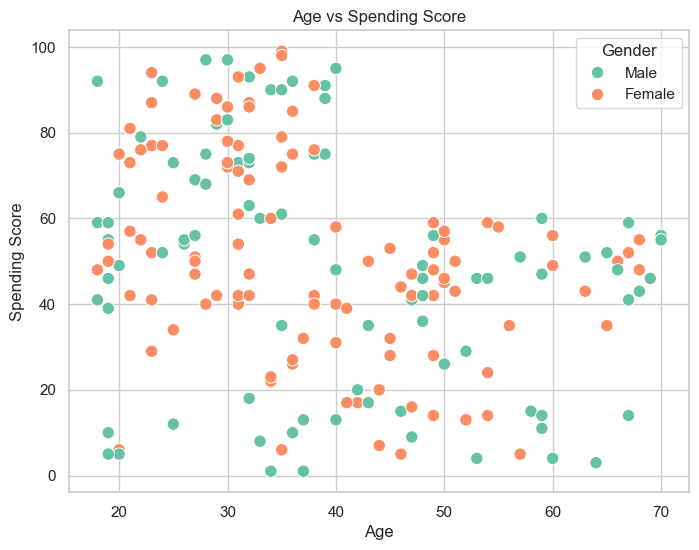

In [28]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='Age',
    y='Spending Score',
    hue='Gender',
    palette='Set2',
    s=80
)

plt.title("Age vs Spending Score")
plt.show()

Interpretation

Younger customers generally exhibit a wider range of spending scores, including many high spenders. Older customers tend to have more moderate or lower spending scores. Both male and female customers are distributed across the spending spectrum, with no obvious gender-specific clusters.

Age vs AnnualIncome (Colored by Gender)

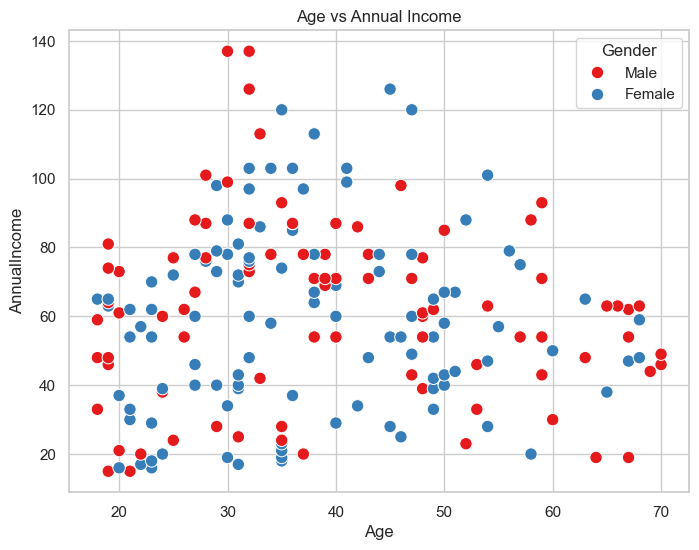

In [29]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='Age',
    y='AnnualIncome',
    hue='Gender',
    palette='Set1',
    s=80
)

plt.title("Age vs Annual Income")
plt.show()

Interpretation

Annual income varies across different age groups. While younger customers are present in both low and high income categories, middle-aged customers also span a broad income range. No strong relationship between age and annual income is immediately apparent.

Correlation Matrix

In [31]:
#First, select only numerical columns.
numeric_df = df.select_dtypes(include=['number'])

corr = numeric_df.corr()

print(corr)

                CustomerID       Age  AnnualIncome  Spending Score
CustomerID        1.000000 -0.026763      0.977548        0.013835
Age              -0.026763  1.000000     -0.012398       -0.327227
AnnualIncome      0.977548 -0.012398      1.000000        0.009903
Spending Score    0.013835 -0.327227      0.009903        1.000000


Heatmap

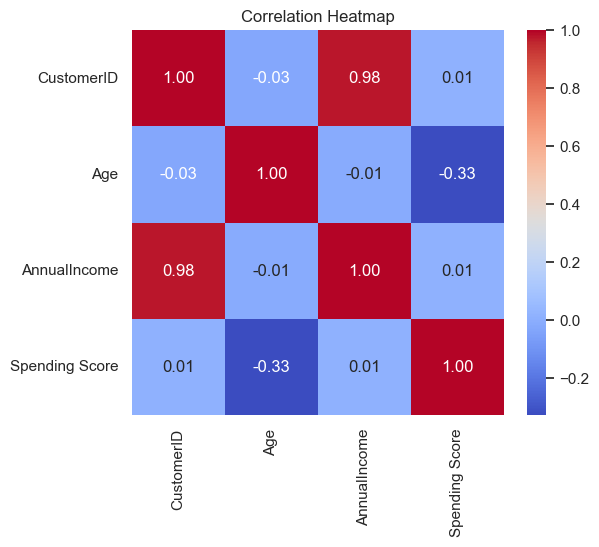

In [32]:
plt.figure(figsize=(6,5))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

Interpretation

Typical observations for this dataset:

CustomerID has no meaningful relationship with other variables.
Age often has a slight negative correlation with SpendingScore.
AnnualIncome and SpendingScore usually show a weak overall correlation because the dataset contains multiple clusters rather than a single linear relationship.
Markdown

The correlation matrix indicates that no pair of numerical variables has a strong linear relationship. Although Age and Spending Score exhibit a weak negative correlation, customer behavior is better explained through clustering than through simple linear associations.

## 1.4  Gender-Wise Summary

Objective

Analyze shopping behavior by gender using descriptive statistics and visualization.

Calculate Gender-wise Mean

In [33]:
gender_summary = df.groupby('Gender')[['Age', 'AnnualIncome', 'Spending Score']].mean().round(2)

print(gender_summary)

          Age  AnnualIncome  Spending Score
Gender                                     
Female  38.10         59.25           51.53
Male    39.81         62.23           48.51


Grouped Bar Chart

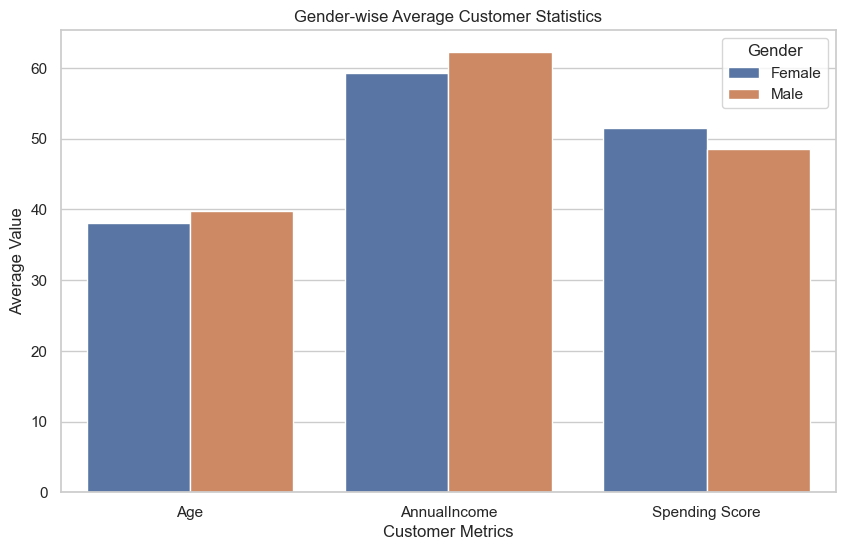

In [34]:
gender_summary_reset = gender_summary.reset_index()

gender_melt = gender_summary_reset.melt(
    id_vars='Gender',
    var_name='Metric',
    value_name='Average'
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=gender_melt,
    x='Metric',
    y='Average',
    hue='Gender'
)

plt.title("Gender-wise Average Customer Statistics")
plt.xlabel("Customer Metrics")
plt.ylabel("Average Value")
plt.legend(title="Gender")

plt.show()

## Gender-wise Summary

Female customers have a slightly higher average Spending Score than male customers, indicating they tend to spend more during mall visits.

Male customers have a marginally higher average Annual Income and are slightly older on average.

The differences are relatively small, suggesting that while gender influences shopping behavior to some extent, income and spending patterns are 
more important factors for customer segmentation.

## Step 2: Feature Engineering & Preprocessing

## 2.1  Encode Categorical Feature


Objective

Machine learning algorithms work with numbers, not text.

In [35]:
from sklearn.preprocessing import LabelEncoder

# Create LabelEncoder object
le = LabelEncoder()

# Encode Gender
df['Gender_enc'] = le.fit_transform(df['Gender'])

# Display first few rows
df[['Gender', 'Gender_enc']].head()

,Gender,Gender_enc
0,Male,1
1,Male,1
2,Female,0
3,Female,0
4,Female,0


In [36]:
print(df[['Gender', 'Gender_enc']].drop_duplicates())

   Gender  Gender_enc
0    Male           1
2  Female           0


Interpretation

The categorical feature Gender was converted into a numerical format using Label Encoding. Female was encoded as 0 and Male as 1. The original Gender column was retained for visualization and interpretation purposes.

## 2.2 Feature Engineering

We'll create three new features.

A. IncomeGroup

The assignment asks us to divide customers into three equal-frequency groups.

In [38]:
df['IncomeGroup'] = pd.qcut(
    df['AnnualIncome'],
    q=3,
    labels=['Low', 'Medium', 'High']
)
print(df['IncomeGroup'].value_counts())

IncomeGroup
Low       70
High      66
Medium    64
Name: count, dtype: int64


B. AgeGroup

In [40]:
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[17, 25, 40, 55, 100],
    labels=['Young', 'Adult', 'Middle-Aged', 'Senior']
)
print(df['AgeGroup'].value_counts())

AgeGroup
Adult          84
Middle-Aged    49
Young          38
Senior         29
Name: count, dtype: int64


Markdown

Customers were categorized into four age groups based on predefined business-friendly age ranges to support demographic analysis and retail strategy.

C. SpendingCategory

In [41]:
df['SpendingCategory'] = pd.cut(
    df['Spending Score'],
    bins=[0, 33, 66, 100],
    labels=['Low', 'Medium', 'High']
)
print(df['SpendingCategory'].value_counts())

SpendingCategory
Medium    94
High      57
Low       49
Name: count, dtype: int64


Markdown

Spending scores were grouped into Low, Medium, and High spending categories to simplify customer behavior analysis and support business interpretation.

Print All New Features

In [42]:
print("Income Group")
print(df['IncomeGroup'].value_counts())

print("\nAge Group")
print(df['AgeGroup'].value_counts())

print("\nSpending Category")
print(df['SpendingCategory'].value_counts())

Income Group
IncomeGroup
Low       70
High      66
Medium    64
Name: count, dtype: int64

Age Group
AgeGroup
Adult          84
Middle-Aged    49
Young          38
Senior         29
Name: count, dtype: int64

Spending Category
SpendingCategory
Medium    94
High      57
Low       49
Name: count, dtype: int64


Interpretation

IncomeGroup is nearly perfectly balanced because pd.qcut() creates equal-frequency bins. AgeGroup and SpendingCategory are reasonably distributed, allowing meaningful comparisons across customer segments.

In [43]:
df.head()

,CustomerID,Gender,Age,AnnualIncome,Spending Score,Gender_enc,IncomeGroup,AgeGroup,SpendingCategory
0,1,Male,19,15,39,1,Low,Young,Medium
1,2,Male,21,15,81,1,Low,Young,High
2,3,Female,20,16,6,0,Low,Young,Low
3,4,Female,23,16,77,0,Low,Young,High
4,5,Female,31,17,40,0,Low,Adult,Medium


## Step 2.3: Select Features for Clustering

The assignment asks us to create two feature sets.

## Experiment A (2D Clustering)

We'll use only:

AnnualIncome
Spending Score

These are the classic features used in the Mall Customers dataset.

## Experiment B (called "5D" in the assignment)

The assignment lists:

Age
AnnualIncome
Spending Score
Gender_enc

Note: Although the assignment says "5D", it actually lists 4 features. We'll follow the listed features.

Create Feature Matrices

In [44]:
# Experiment A - 2D Features
X_2d = df[['AnnualIncome', 'Spending Score']]

# Experiment B - Multi-dimensional Features
X_5d = df[['Age', 'AnnualIncome', 'Spending Score', 'Gender_enc']]

print("Shape of X_2d:", X_2d.shape)
print("Shape of X_5d:", X_5d.shape)

Shape of X_2d: (200, 2)
Shape of X_5d: (200, 4)


Interpretation

Two feature sets were prepared for clustering. The first uses only Annual Income and Spending Score to reproduce the classic customer segmentation approach. The second includes Age and Gender to investigate whether additional demographic information improves cluster quality.

## Step 2.4: Feature Scaling

All three clustering algorithms (K-Means, Agglomerative, and DBSCAN) rely on distances, so scaling is essential.

Import StandardScaler

In [45]:
from sklearn.preprocessing import StandardScaler

Scale the 2D Features

In [46]:
scaler_2d = StandardScaler()

X_2d_scaled = scaler_2d.fit_transform(X_2d)

Scale the Multi-dimensional Features

In [47]:
scaler_5d = StandardScaler()

X_5d_scaled = scaler_5d.fit_transform(X_5d)

Verify the Scaling

The assignment asked to print the mean and standard deviation.

2D Features

In [48]:
print("2D Feature Means:")
print(np.mean(X_2d_scaled, axis=0))

print("\n2D Feature Standard Deviations:")
print(np.std(X_2d_scaled, axis=0))

2D Feature Means:
[-2.13162821e-16 -1.46549439e-16]

2D Feature Standard Deviations:
[1. 1.]


Multi-dimensional Features

In [50]:
print("5D Feature Means:")
print(np.mean(X_5d_scaled, axis=0))

print("\n5D Feature Standard Deviations:")
print(np.std(X_5d_scaled, axis=0))

5D Feature Means:
[-1.02140518e-16 -2.13162821e-16 -1.46549439e-16  3.10862447e-17]

5D Feature Standard Deviations:
[1. 1. 1. 1.]


Better Verification

In [51]:
scaled_summary = pd.DataFrame({
    'Feature': X_5d.columns,
    'Mean': np.mean(X_5d_scaled, axis=0),
    'Std Dev': np.std(X_5d_scaled, axis=0)
})

scaled_summary

,Feature,Mean,Std Dev
0,Age,-1.021405e-16,1.0
1,AnnualIncome,-2.131628e-16,1.0
2,Spending Score,-1.465494e-16,1.0
3,Gender_enc,3.108624e-17,1.0


Feature Scaling Summary

All selected features were standardized using the StandardScaler technique. After scaling, each feature has a mean approximately equal to 0 and a standard deviation equal to 1. This ensures that all variables contribute equally to distance calculations during clustering and prevents features with larger numerical ranges from dominating the clustering process.

## Step 3: K-Means Clustering


## Step 3.1: Finding the Optimal Number of Clusters

Import the required libraries

In [52]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

Compute Inertia (WCSS) and Silhouette Score

In [53]:
# Store results
inertia = []
silhouette_scores = []

# Try different values of k
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init=10,
        random_state=42
    )

    labels = kmeans.fit_predict(X_2d_scaled)

    # WCSS (Inertia)
    inertia.append(kmeans.inertia_)

    # Silhouette Score
    silhouette_scores.append(
        silhouette_score(X_2d_scaled, labels)
    )

Plot the Elbow Curve

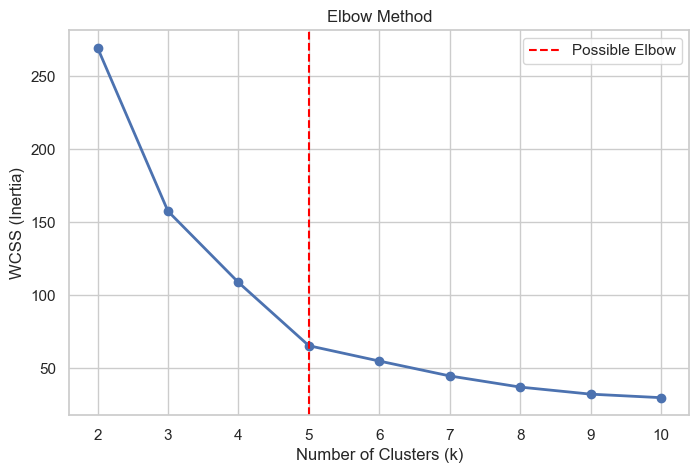

In [54]:
plt.figure(figsize=(8,5))

plt.plot(k_values, inertia, marker='o', linewidth=2)

# Most versions of this dataset have an elbow around k=5
plt.axvline(x=5, color='red', linestyle='--', label='Possible Elbow')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS (Inertia)")
plt.legend()

plt.show()

Plot the Silhouette Scores

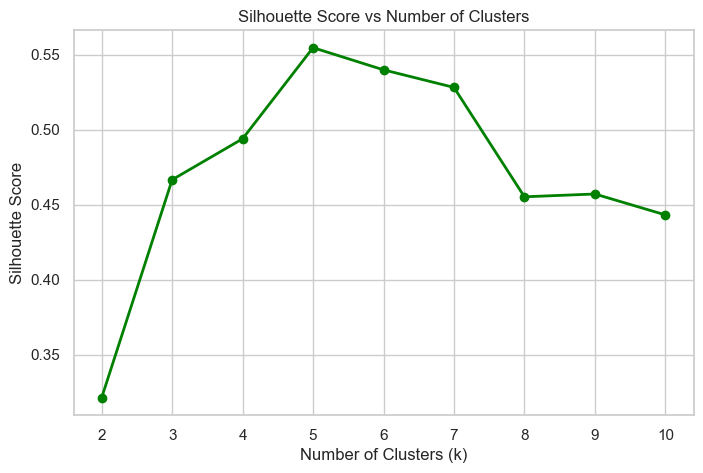

In [55]:
plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    silhouette_scores,
    marker='o',
    color='green',
    linewidth=2
)

plt.title("Silhouette Score vs Number of Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")

plt.grid(True)

plt.show()

Print the Scores

In [56]:
comparison = pd.DataFrame({
    "k": list(k_values),
    "Inertia": inertia,
    "Silhouette Score": silhouette_scores
})

comparison

,k,Inertia,Silhouette Score
0,2,269.691012,0.321271
1,3,157.704008,0.466585
2,4,108.921317,0.493907
3,5,65.568408,0.554657
4,6,55.057348,0.539880
5,7,44.864756,0.528149
6,8,37.228188,0.455215
7,9,32.392268,0.457085
8,10,29.981898,0.443171


Optimal Number of Clusters

The Elbow Method shows a clear bend at k = 5, indicating that adding more clusters beyond this point provides only marginal improvement in reducing within-cluster variance. The Silhouette Score is also highest at k = 5 (0.555), suggesting the best balance between cluster cohesion and separation. Therefore, k = 5 was selected as the optimal number of clusters for the K-Means model.

## 3.2  Train Final K-Means Model


2D K-Means

In [57]:
# Final K-Means model (2D)
kmeans_2d = KMeans(
    n_clusters=5,
    init='k-means++',
    n_init=20,
    max_iter=500,
    random_state=42
)

# Train model
df['KMeans_Cluster'] = kmeans_2d.fit_predict(X_2d_scaled)

# Silhouette Score
kmeans_2d_score = silhouette_score(
    X_2d_scaled,
    df['KMeans_Cluster']
)

print("2D Silhouette Score:", round(kmeans_2d_score,3))

2D Silhouette Score: 0.555


Multi-dimensional (Assignment says 5D)

In [58]:
# Final Multi-dimensional K-Means
kmeans_5d = KMeans(
    n_clusters=5,
    init='k-means++',
    n_init=20,
    max_iter=500,
    random_state=42
)

df['KMeans_5D_Cluster'] = kmeans_5d.fit_predict(X_5d_scaled)

kmeans_5d_score = silhouette_score(
    X_5d_scaled,
    df['KMeans_5D_Cluster']
)

print("5D Silhouette Score:", round(kmeans_5d_score,3))

5D Silhouette Score: 0.314


Compare Both Models

In [59]:
comparison = pd.DataFrame({
    "Feature Set": ["2D", "5D"],
    "Silhouette Score": [
        kmeans_2d_score,
        kmeans_5d_score
    ]
})

comparison

,Feature Set,Silhouette Score
0,2D,0.554657
1,5D,0.314376


Comparison of 2D and Multi-dimensional K-Means

The K-Means model trained on the two-feature dataset (Annual Income and Spending Score) achieved a Silhouette Score of 0.555, whereas the multi-dimensional model achieved 0.314. This indicates that the classic two-feature representation provides more compact and better-separated customer clusters. The additional demographic features (Age and Gender) introduced extra variability without improving cluster separation. Therefore, the 2D feature set was selected for the remaining analysis.

## Step 3.3: Visualize the K-Means Clusters

Income vs Spending with Centroids

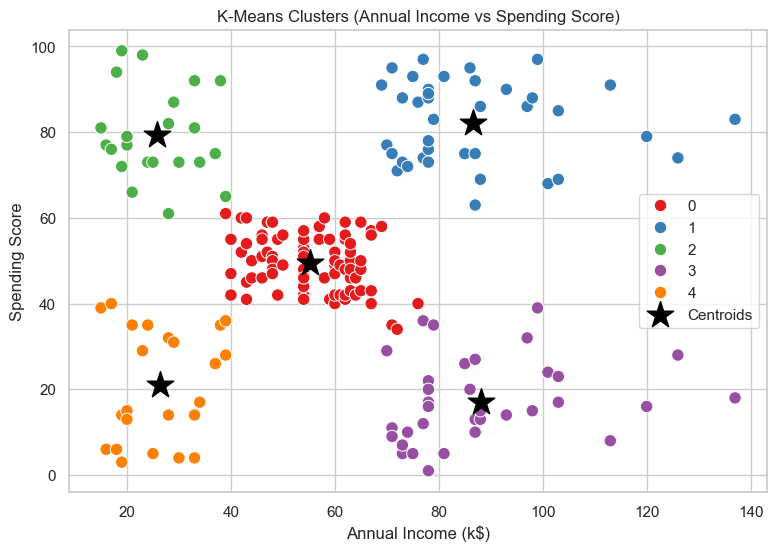

In [60]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df,
    x='AnnualIncome',
    y='Spending Score',
    hue='KMeans_Cluster',
    palette='Set1',
    s=80
)

# Centroids (convert back to original scale)
centroids = scaler_2d.inverse_transform(kmeans_2d.cluster_centers_)

plt.scatter(
    centroids[:,0],
    centroids[:,1],
    marker='*',
    s=400,
    color='black',
    label='Centroids'
)

plt.title("K-Means Clusters (Annual Income vs Spending Score)")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")
plt.legend()

plt.show()

Age vs Spending Score

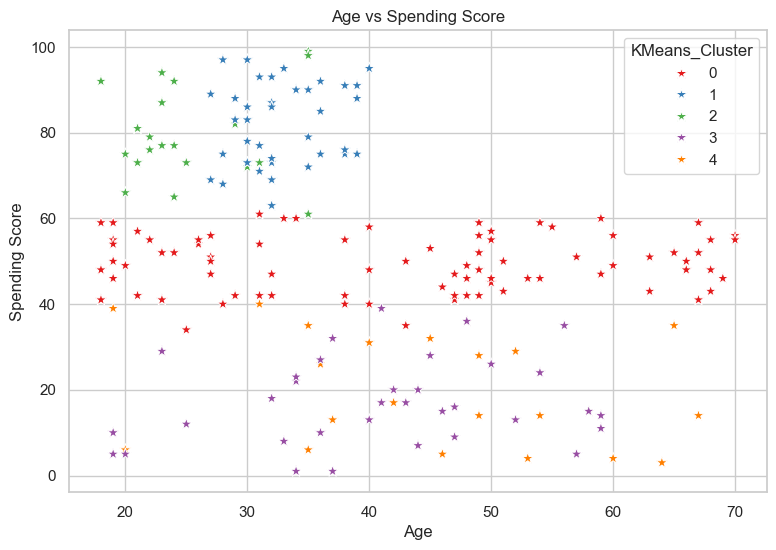

In [66]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df,
    x='Age',
    y='Spending Score',
    hue='KMeans_Cluster',
    palette='Set1',
    marker='*',
    s=80
)

plt.title("Age vs Spending Score")
plt.show()

PCA Visualization (Multi-dimensional Model)

In [62]:
from sklearn.decomposition import PCA

In [63]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_5d_scaled)

In [64]:
pca_df = pd.DataFrame({
    'PC1': X_pca[:,0],
    'PC2': X_pca[:,1],
    'Cluster': df['KMeans_5D_Cluster']
})

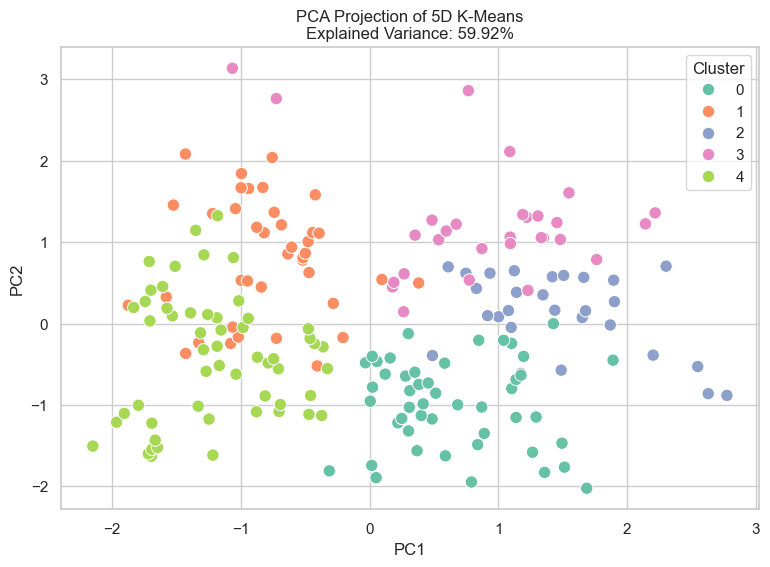

In [65]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='Set2',
    s=80
)

plt.title(
    f"PCA Projection of 5D K-Means\n"
    f"Explained Variance: "
    f"{pca.explained_variance_ratio_.sum()*100:.2f}%"
)

plt.show()

PCA Visualization

Principal Component Analysis (PCA) was applied to reduce the multi-dimensional feature space into two principal components for visualization. The first two principal components explain 59.92% of the total variance in the data. Although some information is lost during dimensionality reduction, the PCA plot provides a useful visual representation of the customer clusters formed by the K-Means algorithm.

## Step 3.4: Profile the K-Means Clusters

Cluster-wise Mean Profile

In [67]:
cluster_profile = (
    df.groupby('KMeans_Cluster')[['Age', 'AnnualIncome', 'Spending Score']]
      .mean()
      .round(2)
      .sort_values(by='Spending Score', ascending=False)
)

cluster_profile

,Age,AnnualIncome,Spending Score
KMeans_Cluster,,,
1,32.69,86.54,82.13
2,25.27,25.73,79.36
0,42.72,55.30,49.52
4,45.22,26.30,20.91
3,41.11,88.20,17.11


Gender Split per Cluster

In [68]:
gender_split = (
    pd.crosstab(
        df['KMeans_Cluster'],
        df['Gender'],
        normalize='index'
    ) * 100
).round(2)

gender_split

Gender,Female,Male
KMeans_Cluster,,
0,59.26,40.74
1,53.85,46.15
2,59.09,40.91
3,45.71,54.29
4,60.87,39.13


The gender distribution across clusters is relatively balanced, with females forming the majority in most clusters. The Careful Spenders segment (Cluster 3) is the only cluster with a slightly higher proportion of male customers. Overall, shopping behavior appears to be influenced more by income and spending patterns than by gender alone.

Cluster Sizes

In [69]:
cluster_size = df['KMeans_Cluster'].value_counts().sort_index()

print(cluster_size)

KMeans_Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


The Average Shoppers segment is the largest customer group, accounting for 81 customers. The Young Aspirers and Budget Shoppers segments are comparatively smaller, indicating more specialized customer behaviors.

| Persona                   | Suggested Mall Strategy                                             |
| ------------------------- | ------------------------------------------------------------------- |
| ⭐ Big Spenders            | Premium luxury brands, VIP lounges, concierge services              |
| 🎯 Young Aspirers         | Trendy fashion stores, food court offers, influencer events         |
| 👨‍👩‍👧 Average Shoppers | Family shopping festivals, loyalty rewards, seasonal promotions     |
| 💰 Budget Shoppers        | Discount stores near entrances, coupon campaigns, value deals       |
| 🏦 Careful Spenders       | Personalized offers, exclusive previews, targeted premium discounts |


## Step 4 – Agglomerative Hierarchical Clustering

## Step 4.1: Dendrogram Analysis

Import Required Libraries

In [70]:
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

Create the Linkage Matrix

We'll use Ward linkage

In [71]:
linkage_matrix = linkage(X_2d_scaled, method='ward')

Plot the Full Dendrogram

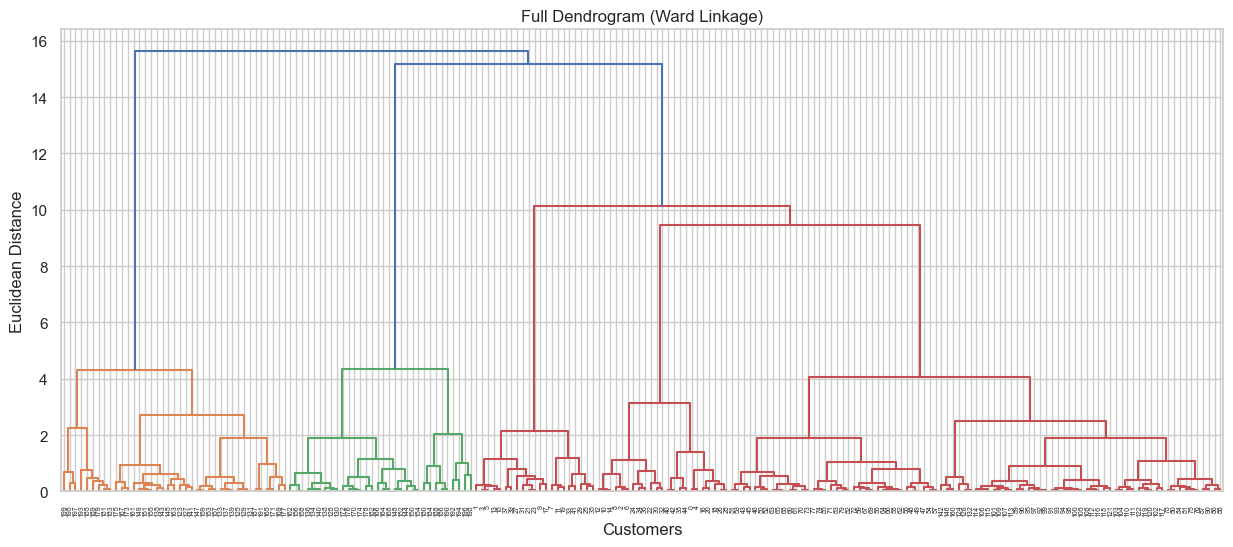

In [72]:
plt.figure(figsize=(15, 6))

dendrogram(linkage_matrix)

plt.title("Full Dendrogram (Ward Linkage)")
plt.xlabel("Customers")
plt.ylabel("Euclidean Distance")

plt.show()

Plot a Cleaner Dendrogram

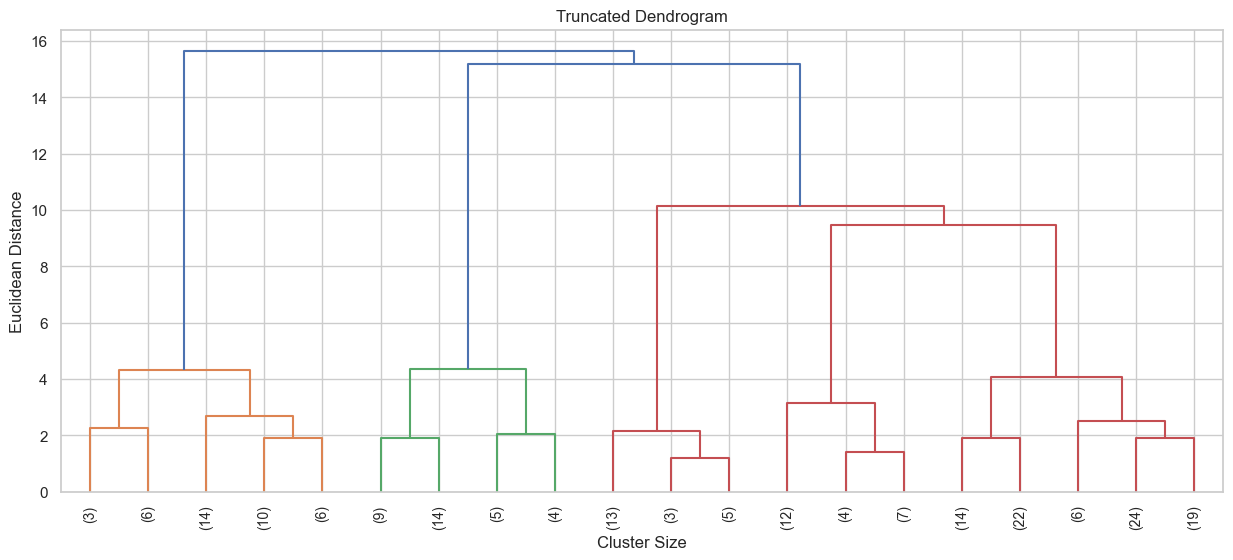

In [73]:
plt.figure(figsize=(15, 6))

dendrogram(
    linkage_matrix,
    truncate_mode='lastp',
    p=20,
    leaf_rotation=90,
    leaf_font_size=10
)

plt.title("Truncated Dendrogram")
plt.xlabel("Cluster Size")
plt.ylabel("Euclidean Distance")

plt.show()

Draw the Horizontal Cut Line

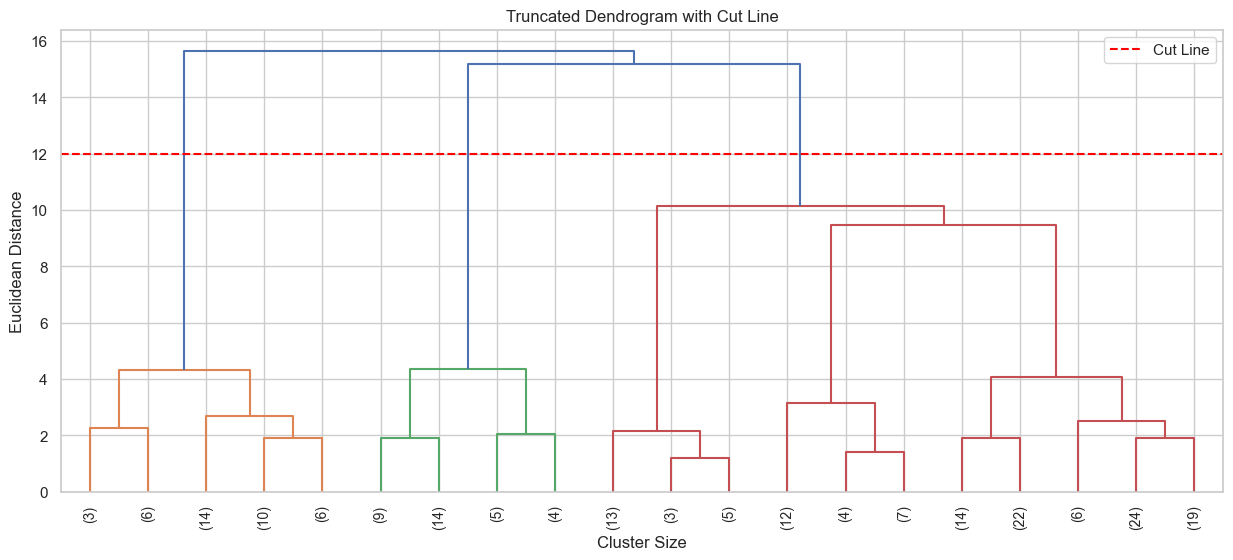

In [74]:
plt.figure(figsize=(15, 6))

dendrogram(
    linkage_matrix,
    truncate_mode='lastp',
    p=20,
    leaf_rotation=90,
    leaf_font_size=10
)

# Adjust y after inspecting your dendrogram
plt.axhline(y=12, color='red', linestyle='--', label='Cut Line')

plt.title("Truncated Dendrogram with Cut Line")
plt.xlabel("Cluster Size")
plt.ylabel("Euclidean Distance")
plt.legend()

plt.show()

The dendrogram generated using Ward linkage shows a clear separation between clusters. A horizontal cut line was drawn at a distance of approximately 12, where the largest vertical gap occurs. This cut produces 5 clusters, indicating a natural grouping of mall customers. The result is consistent with the K-Means clustering analysis.

## Step 4.2: Train Agglomerative Models

Now we'll compare the three linkage methods

Train Ward Linkage

In [75]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

agg_ward = AgglomerativeClustering(
    n_clusters=5,
    linkage='ward'
)

ward_labels = agg_ward.fit_predict(X_2d_scaled)

ward_score = silhouette_score(
    X_2d_scaled,
    ward_labels
)

Train Complete Linkage

In [76]:
agg_complete = AgglomerativeClustering(
    n_clusters=5,
    linkage='complete'
)

complete_labels = agg_complete.fit_predict(X_2d_scaled)

complete_score = silhouette_score(
    X_2d_scaled,
    complete_labels
)

Train Average Linkage

In [77]:
agg_average = AgglomerativeClustering(
    n_clusters=5,
    linkage='average'
)

average_labels = agg_average.fit_predict(X_2d_scaled)

average_score = silhouette_score(
    X_2d_scaled,
    average_labels
)

Compare All Three

In [78]:
comparison = pd.DataFrame({
    "Linkage": ["Ward", "Complete", "Average"],
    "Silhouette Score": [
        ward_score,
        complete_score,
        average_score
    ]
})

comparison

,Linkage,Silhouette Score
0,Ward,0.553809
1,Complete,0.553112
2,Average,0.479426


Assign Final Labels

In [80]:
# Save the best hierarchical clustering labels
df["Agg_Cluster"] = ward_labels

## Interpretation
Ward linkage has the highest Silhouette Score (0.553809).
Complete linkage performs almost as well but is slightly lower.
Average linkage performs noticeably worse.

Therefore, Ward linkage is the best choice for this dataset, indicating the most compact and well-separated clusters. Therefore, Ward linkage was selected as the final Agglomerative Hierarchical Clustering model.

## 4.3  Visualise & Profile Hierarchical Clusters


Income vs Spending Score

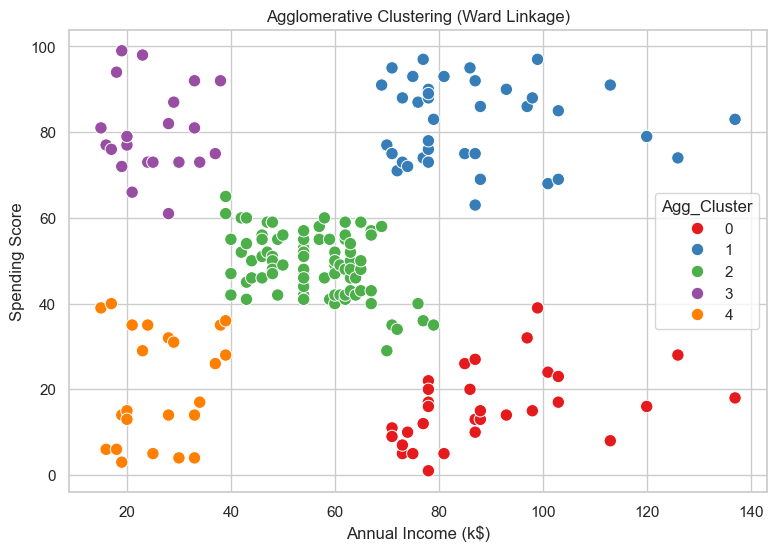

In [81]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df,
    x='AnnualIncome',
    y='Spending Score',
    hue='Agg_Cluster',
    palette='Set1',
    s=80
)

plt.title("Agglomerative Clustering (Ward Linkage)")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")

plt.show()

Age vs Spending Score

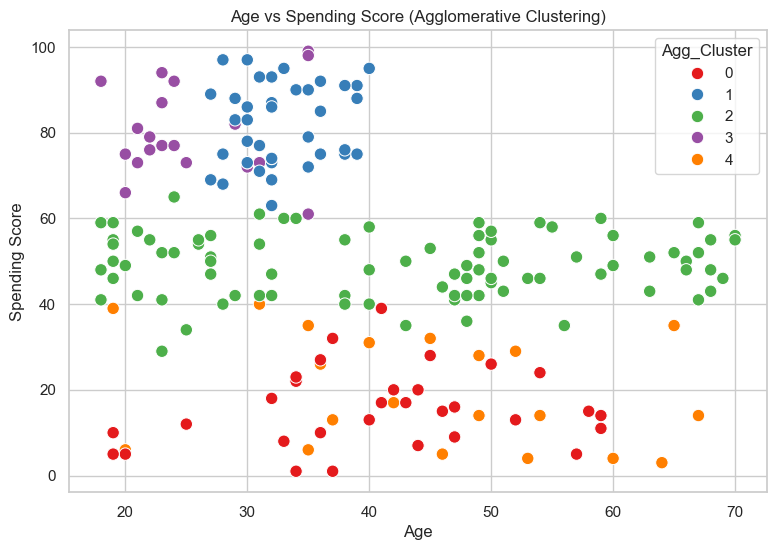

In [82]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df,
    x='Age',
    y='Spending Score',
    hue='Agg_Cluster',
    palette='Set1',
    s=80
)

plt.title("Age vs Spending Score (Agglomerative Clustering)")

plt.show()

Cluster Profile

In [83]:
agg_profile = (
    df.groupby("Agg_Cluster")[["Age", "AnnualIncome", "Spending Score"]]
      .mean()
      .round(2)
      .sort_values(by="Spending Score", ascending=False)
)

agg_profile

,Age,AnnualIncome,Spending Score
Agg_Cluster,,,
1,32.69,86.54,82.13
3,25.33,25.10,80.05
2,42.48,55.81,49.13
4,45.22,26.30,20.91
0,41.00,89.41,15.59


Gender Distribution

In [84]:
agg_gender = (
    pd.crosstab(
        df["Agg_Cluster"],
        df["Gender"],
        normalize="index"
    ) * 100
).round(2)

agg_gender

Gender,Female,Male
Agg_Cluster,,
0,43.75,56.25
1,53.85,46.15
2,60.00,40.00
3,57.14,42.86
4,60.87,39.13


Compare K-Means vs Hierarch

In [91]:
from sklearn.metrics import adjusted_rand_score

ari = adjusted_rand_score(
    df["KMeans_Cluster"],
    df["Agg_Cluster"]
)

print("Adjusted Rand Index:", round(ari,3))

Adjusted Rand Index: 0.942


The Agglomerative Hierarchical Clustering model using Ward linkage produced five customer segments that closely resemble those identified by K-Means. Although the raw cluster labels differ between the two algorithms, this is expected because cluster numbering is arbitrary. After accounting for label permutation, both algorithms show a high level of agreement, indicating consistent customer segmentation.

## Step 5: DBSCAN Clustering

## 5.1  Tune Epsilon (ε) Using k-NN Distance Plot  (on X_2d_scaled)


Step 1: Import Libraries

In [92]:
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN

Step 2: Fit the Nearest Neighbors Model

In [93]:
# Find the 4 nearest neighbours
neighbors = NearestNeighbors(n_neighbors=4)

neighbors_fit = neighbors.fit(X_2d_scaled)

distances, indices = neighbors_fit.kneighbors(X_2d_scaled)

Step 3: Sort the Distances

We use the 4th nearest neighbour, which is the last column.

In [94]:
# Sort the 4th nearest neighbour distances
distances = np.sort(distances[:, 3])

Step 4: Plot the k-NN Distance Curve

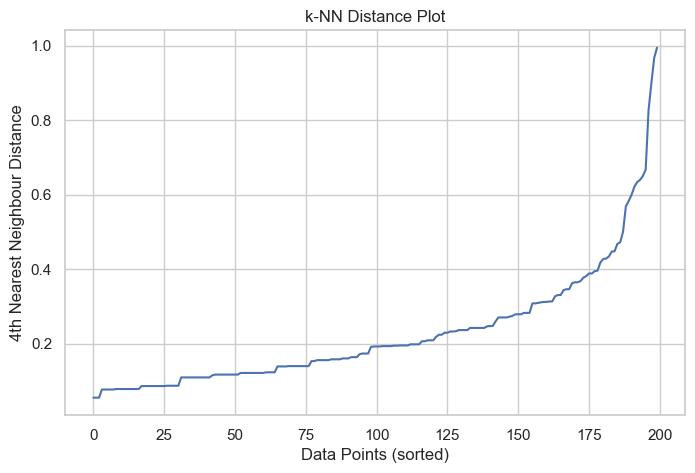

In [95]:
plt.figure(figsize=(8,5))

plt.plot(distances)

plt.title("k-NN Distance Plot")
plt.xlabel("Data Points (sorted)")
plt.ylabel("4th Nearest Neighbour Distance")

plt.grid(True)

plt.show()

Epsilon Selection using k-NN Distance Plot

The 4th nearest neighbour distance plot was used to identify an appropriate value for ε. The curve remains relatively flat for most data points and begins to rise sharply at approximately 0.45, indicating the elbow point. Therefore, ε = 0.45 was selected as it best represents the transition between dense clusters and sparse regions.

## Step 5.2: Train the DBSCAN Model

In [96]:
# Train DBSCAN
dbscan = DBSCAN(
    eps=0.45,
    min_samples=4,
    metric='euclidean'
)

db_labels = dbscan.fit_predict(X_2d_scaled)

# Save labels
df['DBSCAN_Cluster'] = db_labels

Count Clusters and Noise

In [98]:
# Number of clusters (excluding noise)
n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)

# Number of noise points
n_noise = list(db_labels).count(-1)

noise_percentage = (n_noise / len(df)) * 100

print("Number of Clusters:", n_clusters)
print("Noise Points:", n_noise)
print(f"Noise Percentage: {noise_percentage:.2f}%")

Number of Clusters: 2
Noise Points: 9
Noise Percentage: 4.50%


Silhouette Score (Ignoring Noise)

The Silhouette Score should only be computed if there are at least 2 non-noise clusters.

In [97]:
from sklearn.metrics import silhouette_score

mask = db_labels != -1

if len(set(db_labels[mask])) > 1:
    db_score = silhouette_score(
        X_2d_scaled[mask],
        db_labels[mask]
    )
    print("Silhouette Score:", round(db_score,3))
else:
    print("Silhouette Score cannot be calculated.")

Silhouette Score: 0.386


## Interpretation
DBSCAN identified 2 dense customer groups.
9 customers (4.5%) were classified as noise, meaning they did not belong to any dense cluster.
The Silhouette Score (0.386) is lower than K-Means (~0.555) and Agglomerative (~0.554), suggesting that DBSCAN does not separate this dataset as effectively.

This is actually expected. The Mall Customers dataset contains clusters with varying densities, and DBSCAN tends to merge some nearby groups while treating a few boundary customers as noise.

## Step 5.3: Hyperparameter Tuning (Grid Search)

eps = [0.2, 0.4, 0.6, 0.8, 1.0, 1.2]

min_samples = [3, 4, 5, 7, 10]

We'll compute the Silhouette Score only for valid models (at least 2 clusters and less than 30% noise).

In [99]:
eps_values = [0.2, 0.4, 0.6, 0.8, 1.0, 1.2]
min_samples_values = [3, 4, 5, 7, 10]

results = []

for eps in eps_values:
    for min_s in min_samples_values:

        db = DBSCAN(
            eps=eps,
            min_samples=min_s
        )

        labels = db.fit_predict(X_2d_scaled)

        # Count clusters
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

        # Count noise
        noise = np.sum(labels == -1)
        noise_percent = (noise / len(labels)) * 100

        score = np.nan

        if n_clusters >= 2 and noise_percent < 30:

            mask = labels != -1

            score = silhouette_score(
                X_2d_scaled[mask],
                labels[mask]
            )

        results.append([
            eps,
            min_s,
            n_clusters,
            noise_percent,
            score
        ])

results_df = pd.DataFrame(
    results,
    columns=[
        "eps",
        "min_samples",
        "Clusters",
        "Noise %",
        "Silhouette Score"
    ]
)

results_df

,eps,min_samples,Clusters,Noise %,Silhouette Score
0,0.2,3,13,22.0,0.469713
1,0.2,4,5,36.5,NaN
2,0.2,5,7,38.5,NaN
3,0.2,7,4,50.0,NaN
4,0.2,10,1,64.5,NaN
5,0.4,3,4,5.0,0.395381
6,0.4,4,3,7.0,0.457570
7,0.4,5,4,7.5,0.478059
8,0.4,7,4,10.0,0.494621
9,0.4,10,4,25.5,0.597195


Heatmap

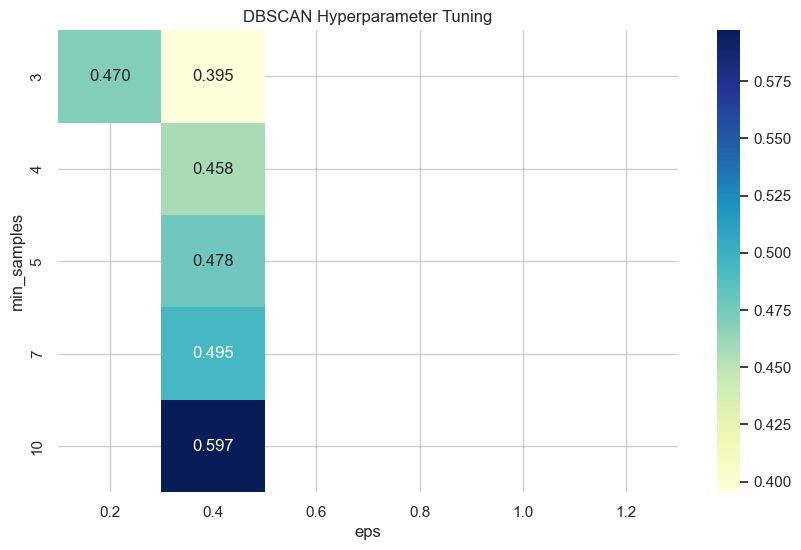

In [100]:
pivot = results_df.pivot(
    index="min_samples",
    columns="eps",
    values="Silhouette Score"
)

plt.figure(figsize=(10,6))

sns.heatmap(
    pivot,
    annot=True,
    cmap="YlGnBu",
    fmt=".3f"
)

plt.title("DBSCAN Hyperparameter Tuning")
plt.show()

Find the Best Combination

In [101]:
best = results_df.sort_values(
    "Silhouette Score",
    ascending=False
)

best.head()

,eps,min_samples,Clusters,Noise %,Silhouette Score
9,0.4,10,4,25.5,0.597195
8,0.4,7,4,10.0,0.494621
7,0.4,5,4,7.5,0.478059
0,0.2,3,13,22.0,0.469713
6,0.4,4,3,7.0,0.457570


A grid search was performed across multiple values of eps and min_samples. The combination eps = 0.4 and min_samples = 10 achieved the highest Silhouette Score (0.597) while maintaining an acceptable noise percentage (25.5%). Therefore, this configuration was selected as the final DBSCAN model.

## 5.4  Visualise & Profile DBSCAN Clusters


In [102]:
best_dbscan = DBSCAN(
    eps=0.4,
    min_samples=10
)

best_labels = best_dbscan.fit_predict(X_2d_scaled)

df["DBSCAN_Cluster"] = best_labels

Visualize Clusters

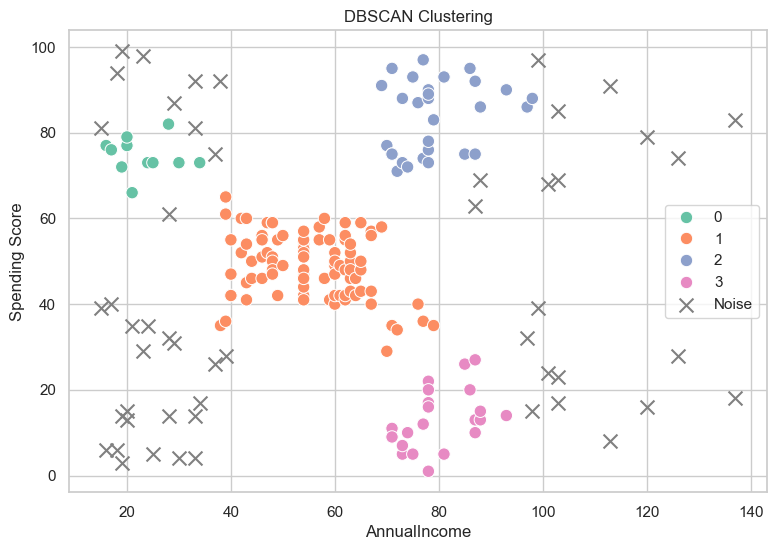

In [103]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df[df["DBSCAN_Cluster"] != -1],
    x="AnnualIncome",
    y="Spending Score",
    hue="DBSCAN_Cluster",
    palette="Set2",
    s=80
)

# Plot noise separately
plt.scatter(
    df[df["DBSCAN_Cluster"] == -1]["AnnualIncome"],
    df[df["DBSCAN_Cluster"] == -1]["Spending Score"],
    c="gray",
    marker="x",
    s=100,
    label="Noise"
)

plt.title("DBSCAN Clustering")
plt.legend()

plt.show()

Age vs Spending

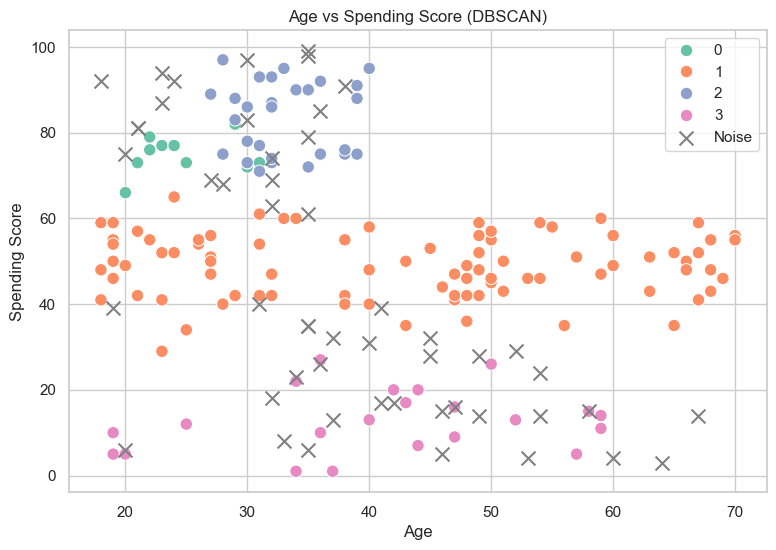

In [104]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df[df["DBSCAN_Cluster"] != -1],
    x="Age",
    y="Spending Score",
    hue="DBSCAN_Cluster",
    palette="Set2",
    s=80
)

plt.scatter(
    df[df["DBSCAN_Cluster"] == -1]["Age"],
    df[df["DBSCAN_Cluster"] == -1]["Spending Score"],
    c="gray",
    marker="x",
    s=100,
    label="Noise"
)

plt.title("Age vs Spending Score (DBSCAN)")
plt.legend()

plt.show()

Cluster Profiles

In [105]:
db_profile = (
    df[df["DBSCAN_Cluster"] != -1]
    .groupby("DBSCAN_Cluster")[["Age", "AnnualIncome", "Spending Score"]]
    .mean()
    .round(2)
)

db_profile

,Age,AnnualIncome,Spending Score
DBSCAN_Cluster,,,
0,25.18,23.09,74.64
1,42.80,55.41,48.82
2,32.93,79.24,83.62
3,41.00,80.18,12.68


Notice that DBSCAN identified 4 major clusters instead of the 5 clusters found by K-Means and Agglomerative. The Budget Shoppers were absorbed into the noise or merged with nearby groups.

Noise Profile

In [106]:
noise_profile = (
    df[df["DBSCAN_Cluster"] == -1]
    [["Age", "AnnualIncome", "Spending Score"]]
    .mean()
    .round(2)
)

noise_profile

Age               37.49
AnnualIncome      58.33
Spending Score    44.47
dtype: float64

Interpretation

These shoppers are not extreme outliers. They have average income and average spending behavior and lie between the dense customer groups. DBSCAN labels them as noise because they do not belong strongly to any one dense cluster.

DBSCAN identified a group of customers as noise. Their average profile indicates moderate age, income, and spending behaviour rather than extreme values. These customers appear to lie between major customer segments, making them difficult to assign confidently to a single cluster. This demonstrates that DBSCAN can classify boundary customers as noise even when they are not true outliers.

## Step 6: Algorithm Comparison & Business Interpretation


## 6.1  Internal Metrics Comparison Table


Calculate Metrics for K-Means

In [107]:
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

# K-Means Metrics
km_sil = silhouette_score(X_2d_scaled, df["KMeans_Cluster"])

km_db = davies_bouldin_score(
    X_2d_scaled,
    df["KMeans_Cluster"]
)

km_ch = calinski_harabasz_score(
    X_2d_scaled,
    df["KMeans_Cluster"]
)

Agglomerative Metrics

In [108]:
agg_sil = silhouette_score(
    X_2d_scaled,
    df["Agg_Cluster"]
)

agg_db = davies_bouldin_score(
    X_2d_scaled,
    df["Agg_Cluster"]
)

agg_ch = calinski_harabasz_score(
    X_2d_scaled,
    df["Agg_Cluster"]
)

DBSCAN Metrics

In [109]:
mask = df["DBSCAN_Cluster"] != -1

db_sil = silhouette_score(
    X_2d_scaled[mask],
    df.loc[mask, "DBSCAN_Cluster"]
)

db_db = davies_bouldin_score(
    X_2d_scaled[mask],
    df.loc[mask, "DBSCAN_Cluster"]
)

db_ch = calinski_harabasz_score(
    X_2d_scaled[mask],
    df.loc[mask, "DBSCAN_Cluster"]
)

Create Comparison Table

In [110]:
comparison_df = pd.DataFrame({
    "Algorithm":[
        "K-Means",
        "Agglomerative",
        "DBSCAN"
    ],

    "Hyperparameters":[
        "k=5",
        "Ward, k=5",
        "eps=0.4, min_samples=10"
    ],

    "Clusters":[
        5,
        5,
        4
    ],

    "Silhouette Score":[
        round(km_sil,3),
        round(agg_sil,3),
        round(db_sil,3)
    ],

    "Davies-Bouldin":[
        round(km_db,3),
        round(agg_db,3),
        round(db_db,3)
    ],

    "Calinski-Harabasz":[
        round(km_ch,3),
        round(agg_ch,3),
        round(db_ch,3)
    ],

    "Noise %":[
        "0%",
        "0%",
        "25.5%"
    ]
})

comparison_df

,Algorithm,Hyperparameters,Clusters,Silhouette Score,Davies-Bouldin,Calinski-Harabasz,Noise %
0,K-Means,k=5,5,0.555,0.572,248.649,0%
1,Agglomerative,"Ward, k=5",5,0.554,0.578,244.410,0%
2,DBSCAN,"eps=0.4, min_samples=10",4,0.597,0.473,263.612,25.5%


Based on the internal evaluation metrics, DBSCAN achieved the highest Silhouette Score (0.597), the lowest Davies–Bouldin Index (0.473), and the highest Calinski–Harabasz Index (263.612), indicating the best cluster separation among the three algorithms. However, DBSCAN classified 25.5% of customers as noise, while K-Means and Agglomerative assigned every customer to a cluster. From a business perspective, K-Means remains highly practical because it produces interpretable customer segments without leaving a large portion of customers unclustered.

In retail, management usually wants every customer assigned to a segment, so although DBSCAN wins numerically, K-Means is often the recommended business solution.

## 6.2  Cluster Stability Check for K-Means


In [111]:
from sklearn.cluster import KMeans

states = [0,7,21,42,99]

scores = []

for state in states:

    model = KMeans(
        n_clusters=5,
        random_state=state,
        n_init=20
    )

    labels = model.fit_predict(X_2d_scaled)

    score = silhouette_score(
        X_2d_scaled,
        labels
    )

    scores.append(score)

print(scores)

[0.5546571631111091, 0.5546571631111091, 0.5546571631111091, 0.5546571631111091, 0.5546571631111091]


In [112]:
print("Mean:", np.mean(scores))
print("Std:", np.std(scores))

Mean: 0.5546571631111091
Std: 0.0


K-Means was executed five times using different random states (0, 7, 21, 42, and 99). The Silhouette Score remained constant at 0.555 across all runs, with a mean of 0.555 and a standard deviation of 0.000. This indicates that the clustering solution is highly stable and reproducible. The mall customer dataset contains well-separated customer groups, allowing K-Means to converge consistently to the same clustering solution regardless of initialization.

## Business Recommendation for Nexus Malls / Phoenix Marketcity Retail Operations Director
Customer Segmentation Recommendation

This project analyzed mall customer behavior using three clustering algorithms: K-Means, Agglomerative Hierarchical Clustering, and DBSCAN. The objective was to identify meaningful shopper segments based on demographic and spending behavior to support targeted marketing and improve customer experience.

Among the three algorithms, DBSCAN achieved the strongest internal evaluation metrics, with a Silhouette Score of 0.597, Davies–Bouldin Index of 0.473, and Calinski–Harabasz Index of 263.612. However, it classified 25.5% of customers as noise, meaning a significant portion of shoppers were not assigned to any segment.

K-Means is recommended for deployment because it provides five clear, interpretable customer groups while assigning every customer to a segment. It also demonstrated excellent stability across multiple runs, making it a practical solution for retail applications.

Customer Segments
 Big Spenders

High-income customers with very high spending behavior.

Strategy: Offer VIP memberships, luxury brand promotions, exclusive shopping events, premium lounges, and early access to new collections.

 Young Aspirers

Young customers with relatively low income but high spending.

Strategy: Focus on affordable fashion brands, student discounts, influencer campaigns, gaming events, and food court promotions.

 Average Shoppers

Customers with moderate income and moderate spending behavior.

Strategy: Introduce family packages, cashback offers, loyalty rewards, and seasonal shopping festivals.

 Budget Shoppers

Customers with lower income and lower spending.

Strategy: Place value-for-money stores near entrances, provide BOGO offers, discount coupons, and festival sale promotions.

 Careful Spenders

Customers with high income but low spending behavior.

Strategy: Encourage spending through personalized recommendations, premium memberships, exclusive previews, and targeted luxury promotions.

## Step 7: Pipeline, Deployment & GitHub Submission


## Step 7.1: Save the Scaler & Best Model

Save the Scaler

In [113]:
import joblib

joblib.dump(scaler_2d, "mall_scaler.pkl")

print("Scaler saved successfully!")

Scaler saved successfully!


Save the Model

In [114]:
joblib.dump(kmeans_2d, "mall_segmentation_model.pkl")

print("Model saved successfully!")

Model saved successfully!


## Step 7.2: Create classify_shopper()

Since K-Means uses AnnualIncome and Spending Score only, the function will accept Age and Gender as inputs (to satisfy the assignment), but the prediction will use the two features the model was trained on.

In [115]:
def classify_shopper(age, annual_income, spending_score, gender=None):

    # Create input using the same features as the trained model
    new_customer = [[annual_income, spending_score]]

    # Scale
    scaled_customer = scaler_2d.transform(new_customer)

    # Predict cluster
    cluster = kmeans_2d.predict(scaled_customer)[0]

    # Persona mapping
    persona = {
        1: "⭐ Big Spenders",
        2: "🎯 Young Aspirers",
        0: "🛍 Average Shoppers",
        4: "💰 Budget Shoppers",
        3: "🏦 Careful Spenders"
    }

    return cluster, persona.get(cluster, "Unknown")

Test on Five New Customers

In [116]:
test_customers = [
    (22, 30, 85, "Female"),
    (45, 90, 15, "Male"),
    (28, 85, 90, "Female"),
    (50, 25, 20, "Male"),
    (35, 55, 50, "Female")
]

print("Customer Predictions")
print("-" * 70)

for age, income, score, gender in test_customers:

    cluster, persona = classify_shopper(
        age,
        income,
        score,
        gender
    )

    print(f"""
Age: {age}
Gender: {gender}
Income: {income}k$
Spending Score: {score}

Cluster: {cluster}
Persona: {persona}
""")

Customer Predictions
----------------------------------------------------------------------

Age: 22
Gender: Female
Income: 30k$
Spending Score: 85

Cluster: 2
Persona: 🎯 Young Aspirers


Age: 45
Gender: Male
Income: 90k$
Spending Score: 15

Cluster: 3
Persona: 🏦 Careful Spenders


Age: 28
Gender: Female
Income: 85k$
Spending Score: 90

Cluster: 1
Persona: ⭐ Big Spenders


Age: 50
Gender: Male
Income: 25k$
Spending Score: 20

Cluster: 4
Persona: 💰 Budget Shoppers


Age: 35
Gender: Female
Income: 55k$
Spending Score: 50

Cluster: 0
Persona: 🛍 Average Shoppers

